In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from scipy.stats import spearmanr, rankdata
from joblib import Parallel, delayed
import warnings
import gc
import argparse
from tqdm.auto import tqdm
import glob
import matplotlib.pyplot as plt
import networkx as nx
import re
import sys


In [2]:
#Path to TwINFER code repository
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/"
path_to_simulation_data = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/binomial_partition_check/"
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/binomial_partition/"
os.makedirs(path_to_plot_data, exist_ok = True)


In [3]:
#Common path to data files
path_to_input_data = f"{path_to_code_repo}/simulation_example_input_data/"
base_config = {
    'n_cells': 6000, #Number of cells before division (number of twin pairs)
    'simulation_time_before_division': 1000, #The time used to run the initial cells before division. User must set this time to ensure the population reaches steady state [hours]
    'twin_simulation_time_after_division': 48, #The time twin cells are simulated after division and measurements are stored in the output[hours]
    'twin_measurement_resolution': 1, #The time between each measurement of twin cells [hours]. For example, if twin_sampling_duration is 12 and twin_measurement_resolution is 1, the final dataframe will contain hourly measurements for 12 hours (0 is birth).
    "path_to_connectivity_matrix": f"{path_to_code_repo}/simulation_example_input_data/connectivity_matrix_A_to_B.txt", #path to the connectivity matrix specifying the GRN to simulate
    "param_csv": f"{path_to_input_data}/median_parameter.csv", #Path to the parameters for all genes and interaction terms
    "rows_to_use": [[0,0]], #Rows in the parameter's csv file for each gene - the length should be equal to number of genes in the system. Example - [0,0] will mean use row 0 parameters for both gene 1 and 2
    "output_folder": f"{path_to_simulation_data}", #Path to folder to store simulation 
    "log_file": f"{path_to_code_repo}/example_simulation_output/example_log.jsonl", #Path to the log file
    "type": "A_to_B",  # Name of the network used -- will be in the filename
    "number_of_parallel_parameters": 1, #Number of parameters to be run in parallel
    "number_of_cores_per_parameter": 10, #Number of cores to be used per parameter (number_of_parallel_parameters * number_of_cores_per_parameter = number of cores in your computer)
}

t1 = 1
t2 = 20

### Imports for helper functions

In [4]:
# Calculation functions
import sys
sys.path.append(str(path_to_code_repo))
import importlib
from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers
from TwINFER_function_scripts import infer_with_twinfer

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)
importlib.reload(infer_with_twinfer)

from TwINFER_function_scripts.correlation_analysis_functions import (
    generate_random_shuffle

)

# Helper functions
from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    split_and_merge_simulations,
    get_param_data, 
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

from TwINFER_function_scripts.infer_with_twinfer import (
    infer_with_twinfer
)

In [53]:
def get_many_random_pair_corr(
    path_to_simulation_file,
    base_config,
    t1,
    t2,
    threshold_gene_gene_corr=0.04,
    check_for_steady_state=True,
    plot_correlation_matrices_as_heatmap=True,
    have_any_output=True,
    random_seed=42,
):
    """
    Compute large-scale random-pair correlations across clones and time points
    to generate a null distribution for statistical inference.

    Parameters
    ----------
    path_to_simulation_file : str or list[str]
        Simulation input. Accepted formats:
        - str : a single CSV simulation file.
        - list/tuple with 1 file   : treated as a single CSV (loaded directly).
        - list/tuple with >=2 files: passed to `split_and_merge_simulations()`
                                    to merge clone sets across simulations.
        All files must contain the columns:
        ['clone_id', 'time_step', 'replicate', ...].

    base_config : dict
        Configuration dictionary with required keys:
        - "path_to_connectivity_matrix" : str
        - "param_csv" : str
        - "n_cells" : int
        - "twin_simulation_time_after_division" : int/float
        - "twin_measurement_resolution" : int/float

    t1, t2 : int or float
        Measurement time points.

    threshold_gene_gene_corr : float, optional
        Unused in this function; included for interface consistency.

    check_for_steady_state : bool, optional
        Unused here.

    plot_correlation_matrices_as_heatmap : bool, optional
        Unused here.

    have_any_output : bool, optional
        Unused here.

    random_seed : int, optional
        Seed for reproducible clone shuffling.

    Returns
    -------
    random_stats : dict
        Statistical summary of the shuffled null correlation distribution for
        the pair ("gene_1", "gene_2"):
        - 'all_values'     : flatten of all shuffle correlations
        - 'mean_per_pair'  : per-shuffle mean
        - 'std_per_pair'   : per-shuffle std
        - 'percentile_95'  : 95th percentile of |correlation|
        - 'percentile_100' : max of |correlation|
        - 'global_mean'    : mean over all values
        - 'global_std'     : std over all values
    """

    # --------------------------------------------------
    # Load simulation file(s)
    # --------------------------------------------------
    try:
        if isinstance(path_to_simulation_file, str):
            # Single file
            simulation = pd.read_csv(path_to_simulation_file)

        elif isinstance(path_to_simulation_file, (list, tuple)):
            # List of files
            if len(path_to_simulation_file) == 1:
                # Single file inside list → read directly
                simulation = pd.read_csv(path_to_simulation_file[0])
            elif len(path_to_simulation_file) >= 2:
                # Merge mutliple simulation files
                simulation = split_and_merge_simulations(path_to_simulation_file)
            else:
                raise ValueError("List of simulation files is empty.")

        else:
            raise TypeError("path_to_simulation_file must be a string or list/tuple.")

    except Exception as e:
        raise RuntimeError(f"Error reading simulation file(s): {e}")

    # --------------------------------------------------
    # Load connectivity + parameters
    # --------------------------------------------------
    path_to_connectivity_matrix = base_config["path_to_connectivity_matrix"]
    param_df = pd.read_csv(base_config["param_csv"], index_col=0)

    # Read the interaction matrix and number of genes
    n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
    gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

    # --------------------------------------------------
    # Basic information & sanity checks
    # --------------------------------------------------
    n_clones_simulation = simulation["clone_id"].nunique()

    time_points_base_config = np.arange(
        0,
        base_config["twin_simulation_time_after_division"] + 
        base_config["twin_measurement_resolution"],
        base_config["twin_measurement_resolution"],
    )

    # --------------------------------------------------
    # Randomly split clones into 1:1:2 partition
    # --------------------------------------------------
    np.random.seed(random_seed)
    clone_ids_shuffled = np.random.permutation(n_clones_simulation)

    n1 = n2 = n_clones_simulation // 4
    t1_clones = clone_ids_shuffled[:n1]
    t2_clones = clone_ids_shuffled[n1:n1+n2]
    across_t_clones = clone_ids_shuffled[n1+n2:]

    # Data subsets for each partition
    t1_twins = simulation[(simulation["clone_id"].isin(t1_clones)) &
                          (simulation["time_step"] == t1)]

    t2_twins = simulation[(simulation["clone_id"].isin(t2_clones)) &
                          (simulation["time_step"] == t2)]

    across_t_twin1 = simulation[(simulation["clone_id"].isin(across_t_clones)) &
                                (simulation["time_step"] == t1) &
                                (simulation["replicate"] == 1)]

    across_t_twin2 = simulation[(simulation["clone_id"].isin(across_t_clones)) &
                                (simulation["time_step"] == t2) &
                                (simulation["replicate"] == 2)]

    # Reset indices before concatenation
    t1_twins = t1_twins.reset_index(drop=True)
    t2_twins = t2_twins.reset_index(drop=True)
    across_t_twin1 = across_t_twin1.reset_index(drop=True)
    across_t_twin2 = across_t_twin2.reset_index(drop=True)

    # Combine all partitions
    all_t1_t2_measurements = pd.concat(
        [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
        ignore_index=True
    )

    # --------------------------------------------------
    # Generate shuffled random-pair correlations
    # --------------------------------------------------
    scrambled_random_corr = generate_random_shuffle(
        all_t1_t2_measurements,
        gene_list,
        n_shuffles=10000,
        random_state=42,
    )

    # Only use ("gene_1", "gene_2") to match expected structure
    all_correlations_g1_g2 = scrambled_random_corr[("gene_1", "gene_2")]
    # all_correlations_g2_g3 = scrambled_random_corr[("gene_2", "gene_3")]
    # all_correlations_g1_g3 = scrambled_random_corr[("gene_1", "gene_3")]

    # --------------------------------------------------
    # Compute summary statistics
    # --------------------------------------------------
    random_stats = {
        ("gene_1", "gene_2"):{
        "all_values": all_correlations_g1_g2.flatten(),
        "mean_per_pair": np.mean(all_correlations_g1_g2, axis=0),
        "std_per_pair": np.std(all_correlations_g1_g2, axis=0),
        "percentile_95": np.percentile(np.abs(all_correlations_g1_g2.flatten()), 95),
        "percentile_100": np.percentile(np.abs(all_correlations_g1_g2.flatten()), 100),
        "global_mean": np.mean(all_correlations_g1_g2),
        "global_std": np.std(all_correlations_g1_g2)
        }   

    }

    return random_stats

In [6]:
def process_simulation(path_to_simulation_file, sim_type, rep_id, base_config, t1, t2, gene_names=None):
    """
    Run data from a simulation through TwINFER, extract all correlation matrices, and flatten
    them into gene-pair columns for downstream CSV export.

    Parameters
    ----------
    path_to_simulation_file : str or list
        Path or list of paths to simulation file(s). Can be a single file or a list
        that TwINFER merges when `merge_to_multiple_states=True`.

    sim_type : str
        Label describing the simulation condition (e.g., "A_to_B_low_kon").

    rep_id : int
        Replicate identifier for this simulation run.

    base_config : dict
        Configuration dictionary passed directly to TwINFER.

    t1, t2 : int or float
        Time points used for extracting twin measurements.

    gene_names : list[str], optional
        Names of genes used to label gene-pair matrix columns.
        If None, generic names are created.

    Returns
    -------
    record : dict
        A flattened dictionary containing:
        - simulation metadata
        - gene-gene correlation threshold for (gene_1, gene_2)
        - flattened directional matrix
        - flattened gene-gene correlation matrix
        - flattened random-pair correlation matrix (t2)
        - flattened twin-pair correlation matrices (t1 and t2)
    """

    results = infer_with_twinfer(
        path_to_simulation_file,
        merge_to_multiple_states=True,
        base_config=base_config,
        t1=t1, 
        t2=t2,
        check_for_steady_state=False,
        have_any_output=False, 
        show_scrambled_distribution_gene_correlation=False,
        plot_correlation_matrices_as_heatmap=False, 
        return_gene_corr_thresholds=True, 
        match_sim_details=False,
        seed=101010
    )

    # Base metadata
    record = {
        "sim_type": sim_type,
        "rep_id": rep_id,
        "analysis_key": f"{sim_type}_rep_{rep_id}",
        "gene_gene_threshold": results["gene_corr_thresholds"][("gene_1", "gene_2")]
    }

    def matrix_to_gene_pair_columns(matrix, gene_names, prefix=""):
        """
        Convert a square matrix (N×N) into flat dictionary columns labeled by
        'prefix + gene_i_gene_j'.

        Parameters
        ----------
        matrix : array-like or DataFrame
            Matrix to flatten.

        gene_names : list[str]
            Names for each row/column index.

        prefix : str
            Optional prefix (e.g., 'directional_', 'gene_gene_').

        Returns
        -------
        dict
            Flattened key → value mapping.
        """
        columns = {}
        if matrix is not None:
            matrix_array = np.array(matrix)
            n_genes = len(gene_names) if gene_names else matrix_array.shape[0]

            if gene_names is None:
                gene_names = [f"g{i+1}" for i in range(n_genes)]

            for i in range(matrix_array.shape[0]):
                for j in range(matrix_array.shape[1]):
                    key = f"{prefix}{gene_names[i]}_{gene_names[j]}"
                    columns[key] = matrix_array[i, j]
        return columns

    # All matrices we want to flatten
    matrix_data = {
        "directional": results["direction_matrix"],
        "gene_gene": results["pairwise_gene_gene_correlation_matrix"],
        "random": results["random_pair_correlation_matrix_t2"],
        "twin_t1": results["twin_pair_correlation_matrix_t1"],
        "twin_t2": results["twin_pair_correlation_matrix_t2"]
    }

    # Flatten matrices and add to output dictionary
    for mtype, matrix in matrix_data.items():
        record.update(matrix_to_gene_pair_columns(matrix, gene_names, f"{mtype}_"))

    return record


def save_results_to_csv(results_list, output_dir="results"):
    """
    Save flattened simulation results to multiple CSV files:
    - all_simulation_results.csv (everything combined)
    - one CSV per matrix type (directional, gene_gene, random, twin_t1, twin_t2)
    - summary CSV aggregated over simulation types

    Parameters
    ----------
    results_list : list[dict]
        List of flattened simulation records created by process_simulation().

    output_dir : str
        Directory where all files will be saved.

    Returns
    -------
    df : pandas.DataFrame
        Full combined DataFrame of all results.
    """
    df = pd.DataFrame(results_list)
    os.makedirs(output_dir, exist_ok=True)
    matrix_types = ["directional", "gene_gene", "random", "twin_t1", "twin_t2"]

    # Create separate CSV for each matrix type
    for matrix_type in matrix_types:
        matrix_columns = [c for c in df.columns if c.startswith(f"{matrix_type}_")]

        if matrix_columns:
            metadata_cols = ["sim_type", "rep_id", "analysis_key"]
            subset_cols = metadata_cols + matrix_columns
            subset_df = df[subset_cols].copy()

            # Remove prefix for nicer output
            rename_dict = {col: col.replace(f"{matrix_type}_", "") for col in matrix_columns}
            subset_df.rename(columns=rename_dict, inplace=True)

            file_path = os.path.join(output_dir, f"{matrix_type}_matrix_results.csv")
            subset_df.to_csv(file_path, index=False)
            print(f"✅ Saved {matrix_type} matrix to {file_path}")
    return subset_df

## Run the simulation through TwINFER

In [39]:
#Collect all the simulations needed for figure 2: The 4 scenarios!
tasks = []

# Case 1: A_to_B
sim_folder = f"{path_to_simulation_data}/A_to_B/"
pattern = os.path.join(sim_folder, "df_rows_0_0_*bias_0.5_*.csv")
# pattern = os.path.join(sim_folder, "df_rows_0_1_*_ncells_6000_A_to_B_rep*.csv")
for rep_id, f in enumerate(sorted(glob.glob(pattern))):
    # rep_id = os.path.splitext(os.path.basename(f))[0].split("_rep_")[-1]
    if "k_on" not in f:
        tasks.append((f, "A_to_B", os.path.basename(f)))

# Case 2: A, B no regulation
sim_folder = f"{path_to_simulation_data}/A_B/"
pattern = os.path.join(sim_folder, "df_rows_0_0_*bias_0.5_*.csv")
for rep_id, f in enumerate(glob.glob(pattern)):
    if "k_on" not in f:
        tasks.append((f, "A_B", os.path.basename(f)))

# Case 3: 2 states A_to_B
sim_folder_1 = f"{path_to_simulation_data}/A_to_B_high"
sim_folder_2 =  f"{path_to_simulation_data}/A_to_B_low"

files_1 = [f for f in glob.glob(os.path.join(sim_folder_1, "*.csv"))
           if os.path.basename(f).startswith('df_')]
files_2 = [f for f in glob.glob(os.path.join(sim_folder_2, "*.csv"))
           if os.path.basename(f).startswith('df_')]

pairs = {}
for f in files_1:
    rep_match = re.search(r"bias_0.5_(\d+)", os.path.basename(f))
    if rep_match:
        rep_id = rep_match.group(1)
        key = ("A_to_B_2_states", rep_id)
        pairs.setdefault(key, {'high': None, 'low': None})['high'] = f

for f in files_2:
    rep_match = re.search(r"bias_0.5_(\d+)", os.path.basename(f))
    if rep_match:
        rep_id = rep_match.group(1)
        key = ("A_to_B_2_states", rep_id)
        pairs.setdefault(key, {'high': None, 'low': None})['low'] = f

for (sim_type, rep_id), pair in pairs.items():
    if pair['high'] and pair['low']:
        tasks.append(([pair['high'], pair['low']], sim_type, rep_id))

# Case 4: 2 states, A,B
sim_folder_1 = f"{path_to_simulation_data}/A_B_high/"
sim_folder_2 = f"{path_to_simulation_data}/A_B_low/"

files_1 = [f for f in glob.glob(os.path.join(sim_folder_1, "*.csv"))
           if os.path.basename(f).startswith('df_')]
files_2 = [f for f in glob.glob(os.path.join(sim_folder_2, "*.csv"))
           if os.path.basename(f).startswith('df_')]

pairs = {}
for f in files_1:
    rep_match = re.search(r"bias_0.5_(\d+)", os.path.basename(f))
    if rep_match:
        rep_id = rep_match.group(1)
        key = ("A_B_2_states", rep_id)
        pairs.setdefault(key, {'high': None, 'low': None})['high'] = f

for f in files_2:
    rep_match = re.search(r"bias_0.5_(\d+)", os.path.basename(f))
    if rep_match:
        rep_id = rep_match.group(1)
        key = ("A_B_2_states", rep_id)
        pairs.setdefault(key, {'high': None, 'low': None})['low'] = f

for (sim_type, rep_id), pair in pairs.items():
    if pair['high'] and pair['low']:
        tasks.append(([pair['high'], pair['low']], sim_type, rep_id))



In [40]:
# # ---------- Run all tasks in parallel and save the results in plot_data folder
print("🚀 Starting parallel processing...")

results_list = Parallel(n_jobs=8, backend="loky")(
    delayed(process_simulation)(path, sim_type, rep_id, base_config, t1, t2)
    for path, sim_type, rep_id in tasks
)

# ---------- Save results to CSV ----------
print("\n💾 Saving results to CSV files...")
df = save_results_to_csv(results_list, output_dir = path_to_plot_data)

# ---------- Quick analysis ----------
print(f"\n All simulations processed and saved!")
print(f"Total simulations: {len(df)}")
print(f"Simulation types: {list(df['sim_type'].unique())}")
print(f"Columns created: {len(df.columns)}")

🚀 Starting parallel processing...
Only one simulation file was provided while merge_to_multiple_states was set to True. The file will be used as-is.Only one simulation file was provided while merge_to_multiple_states was set to True. The file will be used as-is.

Only one simulation file was provided while merge_to_multiple_states was set to True. The file will be used as-is.
Only one simulation file was provided while merge_to_multiple_states was set to True. The file will be used as-is.
Only one simulation file was provided while merge_to_multiple_states was set to True. The file will be used as-is.
Only one simulation file was provided while merge_to_multiple_states was set to True. The file will be used as-is.
Only one simulation file was provided while merge_to_multiple_states was set to True. The file will be used as-is.
Only one simulation file was provided while merge_to_multiple_states was set to True. The file will be used as-is.
Could not ascertain corresponding parameter ro

## Test for multiple states

In [41]:
# Load the data
random_correlation_path = f"{path_to_plot_data}/random_matrix_results.csv"
twin_correlation_t1_path= f"{path_to_plot_data}/twin_t1_matrix_results.csv"
random_correlation_data = pd.read_csv(random_correlation_path)
twin_correlation_t1_data = pd.read_csv(twin_correlation_t1_path)

SignificanceResult(statistic=0.03437907753154787, pvalue=0.0001653796215179338)


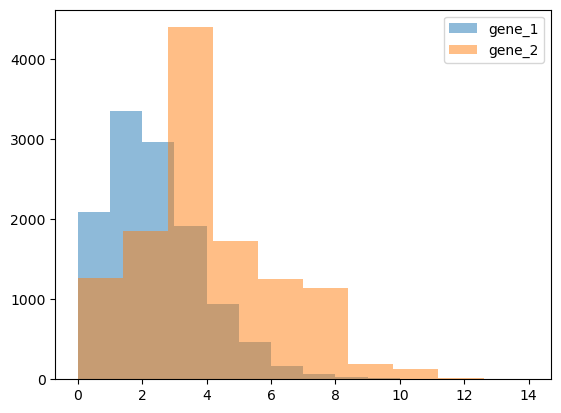

In [38]:
df = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_high_k_on/df_rows_3_3_09082025_220257_ncells_6000_A_to_B_high_k_on_rep_0.csv")
df = df[df['time_step']==1]
df
plt.hist(df['gene_1_mRNA'], label = "gene_1",alpha = 0.5)
plt.hist(df['gene_2_mRNA'], label = "gene_2",alpha = 0.5)
from scipy.stats import spearmanr
print(spearmanr(df['gene_1_mRNA'], df['gene_2_mRNA']))
plt.legend()
plt.show()

## Panel 2a


In [ ]:
gene_gene_corr_data_path = f"{path_to_plot_data}/gene_gene_matrix_results.csv"
gene_gene_corr_data = pd.read_csv(gene_gene_corr_data_path)
gene_gene_corr_data[gene_gene_corr_data['sim_type'] == "A_to_B_2_states"]

/tmp/ipykernel_2847141/1697942211.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(all_values, labels=labels_plot, patch_artist=True, showfliers=True)


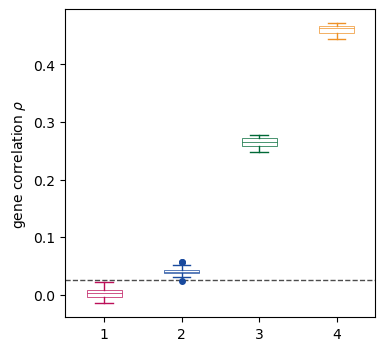

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Set matplotlib to use vector backend and disable clipping
plt.rcParams['svg.fonttype'] = 'none'  # Keep text as text, not paths
plt.rcParams['font.family'] = 'sans-serif'  # Use system fonts

sim_types_to_plot = ['A_B','A_to_B', 'A_to_B_2_states', 'A_B_2_states']
labels_plot = ["1", "2", "3", "4"]
colors = ['#bc0f58', '#194a9e', '#006937', '#ee9127']

# Collect all iteration values for g1_g2 (equivalent to iloc[0,1])
all_values = []
all_thresholds = []

for sim_type in sim_types_to_plot:
    # Filter data for this simulation type
    sim_data = gene_gene_corr_data[gene_gene_corr_data['sim_type'] == sim_type]
    
    # Get g1_g2 values (change column name if different)
    vals = sim_data['g1_g2'].values.tolist()  # or whatever your gene pair column is
    thresholds = sim_data['threshold'].values.tolist()
    
    all_values.append(vals)
    all_thresholds.append(thresholds)

# Flatten thresholds for min/max calculation
flat_thresholds = [item for sublist in all_thresholds for item in sublist]

# --- Main boxplot for gene_gene values ---
fig, ax = plt.subplots(figsize=(4, 4))

# REMOVE ALL BACKGROUNDS
ax.set_facecolor('none')         # Axes background transparent
plt.ylabel(r"gene correlation $\rho$")


# Add mean threshold line
ax.axhline(np.mean(flat_thresholds), 
          linestyle="--", 
          color="black", 
          linewidth=1, 
          alpha=0.7,
          label="Mean threshold")

# Create boxplot
box = ax.boxplot(all_values, labels=labels_plot, patch_artist=True, showfliers=True)

# Style each component with matching color
# Change this line:
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor('none')
    patch.set_edgecolor(color)  # Use set_color() instead of set_edgecolor()
    patch.set_linewidth(0.5)

for whisker, color in zip(box['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)

for cap, color in zip(box['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)

for median, color in zip(box['medians'], colors):
    median.set_color(color)
    median.set_linewidth(0.5)

for flier, color in zip(box['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)
    flier.set_markersize(4)

# DISABLE CLIPPING for all elements (prevents masks in Illustrator)
for element_list in [box['boxes'], box['whiskers'], box['caps'], box['medians']]:
    for element in element_list:
        element.set_clip_on(False)

# # Style inset boxplot with matching colors
# for patch, color in zip(box_inset['boxes'], colors):
#     patch.set_facecolor(color)
#     patch.set_edgecolor(color)

# for whisker, color in zip(box_inset['whiskers'], [c for c in colors for _ in (0, 1)]):
#     whisker.set_color(color)

# for cap, color in zip(box_inset['caps'], [c for c in colors for _ in (0, 1)]):
#     cap.set_color(color)

# for median, color in zip(box_inset['medians'], colors):
#     median.set_color("black")
#     median.set_linewidth(0.5)

# # DISABLE CLIPPING for inset elements too
# for element_list in [box_inset['boxes'], box_inset['whiskers'], box_inset['caps'], box_inset['medians']]:
#     for element in element_list:
#         element.set_clip_on(False)

# plt.savefig(f'{output_folder}/gene_gene_correlation.png', 
#            format='png', 
#            bbox_inches='tight',
#            facecolor='none',      # Transparent figure background
#            edgecolor='none',      # No edge color
#            transparent=True)      # Ensure transparency



# # Save with transparent background and no clipping masks
# plt.savefig(f'{output_folder}/gene_gene_correlation.svg', 
#            format='svg', 
#            bbox_inches='tight',
#            facecolor='none',      # Transparent figure background
#            edgecolor='none',      # No edge color
#            transparent=True)      # Ensure transparency
# plt.savefig(f'{output_folder}/gene_gene_correlation.pdf', 
#            format='pdf', 
#            bbox_inches='tight',
#            facecolor='none',      # Transparent figure background
#            edgecolor='none',      # No edge color
#            transparent=True)      # Ensure transparency

plt.show()

/tmp/ipykernel_2847141/1313740059.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_threshold = ax_threshold.boxplot(all_thresholds, labels=labels_plot,


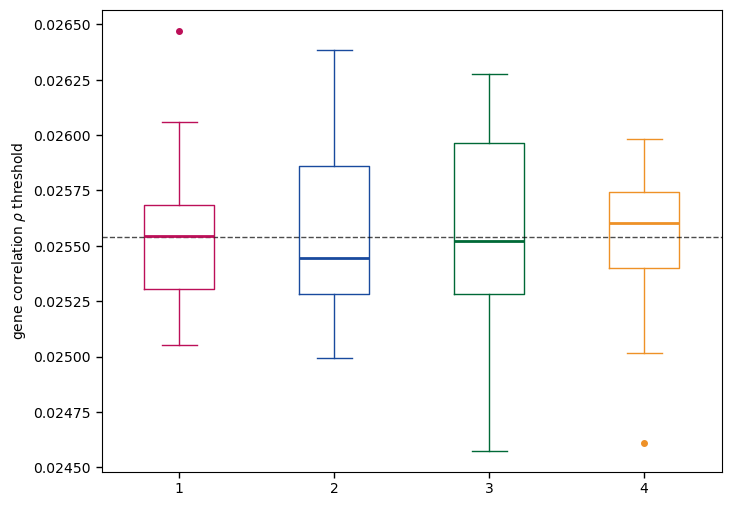

In [46]:
# Create standalone threshold plot
fig_threshold, ax_threshold = plt.subplots(figsize=(8, 6))

# Create threshold boxplot
box_threshold = ax_threshold.boxplot(all_thresholds, labels=labels_plot, 
                                   patch_artist=False, showfliers=True)
ax_threshold.axhline(np.mean(flat_thresholds), linestyle="--", color="black", linewidth=1, alpha=0.7)

# Style threshold boxplot with matching colors
for patch, color in zip(box_threshold['boxes'], colors):
    patch.set_color(color)

for whisker, color in zip(box_threshold['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)

for cap, color in zip(box_threshold['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)

for median, color in zip(box_threshold['medians'], colors):
    median.set_color(color)
    median.set_linewidth(2)

# Style outliers
for flier, color in zip(box_threshold['fliers'], colors):
    if len(flier.get_data()[0]) > 0:
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)
        flier.set_markersize(4)

# DISABLE CLIPPING
for element_list in [box_threshold['boxes'], box_threshold['whiskers'], box_threshold['caps'], box_threshold['medians']]:
    for element in element_list:
        element.set_clip_on(False)

# ax_threshold.set_yticks(np.arange(0.023, 0.0241, 0.0005))

# Style axes
ax_threshold.tick_params(
    axis='both',
    which='both',
    bottom=True, top=False, left=True, right=False,
    # labelbottom=False, labelleft=False,
    length=4, width=1
)
plt.ylabel(r"gene correlation $\rho$ threshold")
# Save standalone threshold plot
# plt.savefig(f'{output_folder}/gene_gene_correlation_threshold_boxplot.svg', 
#            format='svg', 
#            bbox_inches='tight',
#            facecolor='none',
#            edgecolor='none',
#            transparent=True)
# plt.savefig(f'{output_folder}/gene_gene_correlation_threshold_boxplot.pdf', 
#            format='pdf', 
#            bbox_inches='tight',
#            facecolor='none',
#            edgecolor='none',
#            transparent=True)

plt.show()

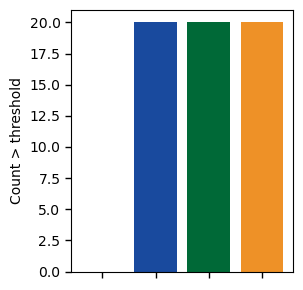

In [47]:
# Count how many values are greater than threshold for each sim_type
counts = []
for i, sim_type in enumerate(sim_types_to_plot):
    # Filter data for this simulation type
    sim_data = gene_gene_corr_data[gene_gene_corr_data['sim_type'] == sim_type]
    
    # Get the g1_g2 values (adjust column name if different)
    vals = sim_data['g1_g2'].values  # Change 'g1_g2' to your actual column name
    threshold = np.mean(all_thresholds[i])
    # Count values >= threshold
    count_greater = np.sum(vals >= threshold)
    counts.append(count_greater)
    
    # Print the values >= threshold
    all_values = vals[vals < threshold]

# Create bar plot
plt.figure(figsize=(3, 3))
bars = plt.bar(sim_types_to_plot, counts, color=colors)

plt.ylabel(f'Count > threshold')
plt.axhline(0, color='black', linewidth=0.5)

plt.tick_params(
    axis='both',
    which='both',
    bottom=True, top=False, left=True, right=False,
    labelbottom=False, labelleft=True,
    length=4, width=1
)

plt.tight_layout()
# plt.savefig(f'{output_folder}/number_points_cross_gene_gene_threshold.png', format='png')
plt.show()

## Panel 2b - single vs multi-state


In [48]:
# Load the data
random_correlation_path = f"{path_to_plot_data}/random_matrix_results.csv"
twin_correlation_t1_path= f"{path_to_plot_data}/twin_t1_matrix_results.csv"
random_correlation_data = pd.read_csv(random_correlation_path)
twin_correlation_t1_data = pd.read_csv(twin_correlation_t1_path)

In [ ]:
# t1 = 1
# t2 = 20
# path_to_A_to_B = f"{path_to_simulation_data}/A_to_B/df_rows_0_1_05082025_160041_ncells_6000_A_to_B_rep_1.csv"
# random_correlation_A_to_B = get_many_random_pair_corr(
#         path_to_A_to_B,
#         base_config,
#         t1, t2,
#         check_for_steady_state=False,
#         have_any_output=False,
#         plot_correlation_matrices_as_heatmap=False
#     )["all_values"]

# path_to_A_B_2_states = [f"{path_to_simulation_data}/A_B_high_k_on/df_rows_3_3_09082025_201359_ncells_6000_A_B_high_k_on_rep_1.csv", f"{path_to_simulation_data}/A_B_low_k_on/df_rows_2_2_09082025_210256_ncells_6000_A_B_low_k_on_rep_1.csv"]
# random_correlation_A_B_2_states = get_many_random_pair_corr(
#         path_to_A_B_2_states,
#         base_config,
#         t1, t2,
#         check_for_steady_state=False,
#         have_any_output=False,
#         plot_correlation_matrices_as_heatmap=False
#     )["all_values"]

# path_to_A_to_B_2_states = [f"{path_to_simulation_data}/A_to_B_high_k_on/df_rows_3_3_09082025_220257_ncells_6000_A_to_B_high_k_on_rep_1.csv", f"{path_to_simulation_data}/A_to_B_low_k_on/df_rows_2_2_09082025_212311_ncells_6000_A_to_B_low_k_on_rep_1.csv"]
# random_correlation_A_to_B_2_states = get_many_random_pair_corr(
#         path_to_A_to_B_2_states,
#         base_config,
#         t1, t2,
#         check_for_steady_state=False,
#         have_any_output=False,
#         plot_correlation_matrices_as_heatmap=False
#     )["all_values"]


In [76]:
import glob
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Function to get all files matching a pattern
def get_all_rep_files(pattern):
    return glob.glob(pattern)

import glob
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Function to get all files matching a pattern
def get_all_rep_files(pattern):
    return glob.glob(pattern)

import re

def process_all_reps_with_twins(file_pattern_or_folders, base_config, t1, t2, twin_data_df, sim_type_name, is_two_state=False):
    all_medians = []
    z_scores = []
    z_score_rand_list = []
    z_threshold_list = []
    if is_two_state:
        # Handle 2-state cases with paired files
        high_k_files = glob.glob(f"{file_pattern_or_folders[0]}/df_rows_*bias_0.5_*.csv")
        low_k_files = glob.glob(f"{file_pattern_or_folders[1]}/df_rows_*bias_0.5_*.csv")
        
        for high_file in high_k_files:
            # Extract rep number from filename
            # extract rep number from high file
            match = re.search(r"bias_0\.5_(\d+)", high_file)
            if match is None:
                continue  # or raise error

            rep_num = str(match.group(1))

            # find matching low-k file with same bias_0.5_<rep>
            matching_low_file = [
                f for f in low_k_files
                if re.search(rf"bias_0\.5_{rep_num}\D", f)
            ]


            
            if matching_low_file:
                file_pair = [high_file, matching_low_file[0]]
                print(f"Processing {sim_type_name} rep {rep_num}: {file_pair}")
                
                try:
                    random_correlation = get_many_random_pair_corr(
                        file_pair,
                        base_config,
                        t1, t2,
                        check_for_steady_state=False,
                        have_any_output=False,
                        plot_correlation_matrices_as_heatmap=False
                    )[("gene_1", "gene_2")]["all_values"]
                    
                    # Calculate median and z-score
                    median_corr = np.median(random_correlation)
                    all_medians.append(median_corr)
                    
                    # Get twin data
                    twin_row = twin_data_df[(twin_data_df['sim_type'] == sim_type_name) & 
                                           (twin_data_df['rep_id'] == rep_num)]
                    random_row = random_correlation_data[(random_correlation_data['sim_type'] == sim_type_name) & 
                                           (random_correlation_data['rep_id'] == rep_num)]
                    if not twin_row.empty:
                        twin_vals = twin_row['g2_g1'].values[0]
                        random_vals = random_row['g2_g1'].values[0]
                        random_mean = np.mean(random_correlation)
                        random_std = np.std(random_correlation)
                        z_score = (twin_vals - random_mean) / random_std
                        z_scores.append(z_score)
                        z_threshold = -10*random_std + random_mean
                        z_threshold_list.append(z_threshold)
                        z_score_rand = (random_vals - random_mean) / random_std
                        z_score_rand_list.append(z_score_rand)
                    else:
                        print(f"Warning: No twin data found for {sim_type_name} rep {rep_num}")
                        z_scores.append(np.nan)
                        
                except Exception as e:
                    print(f"Error processing {file_pair}: {e}")
                    continue
    else:
        # Handle single-state cases
        files = glob.glob(file_pattern_or_folders)
        
        for file_path in files:
            rep_num =  int(match.group(1)) 
            print(f"Processing {sim_type_name} rep {rep_num}: {file_path}")
            
            try:
                random_correlation = get_many_random_pair_corr(
                    file_path,
                    base_config,
                    t1, t2,
                    check_for_steady_state=False,
                    have_any_output=False,
                    plot_correlation_matrices_as_heatmap=False
                )[("gene_1", "gene_2")]["all_values"]
                
                median_corr = np.median(random_correlation)
                all_medians.append(median_corr)
                
                # Get twin data
                twin_row = twin_data_df[(twin_data_df['sim_type'] == sim_type_name) & 
                                    (int(twin_data_df['rep_id']) == rep_num)]
                print(rep_num, sim_type, twin_row)
                random_row = random_correlation_data[(random_correlation_data['sim_type'] == sim_type_name) & 
                                        (random_correlation_data['rep_id'] == rep_num)]
                if not twin_row.empty:
                    twin_vals = twin_row['g2_g1'].values[0]
                    random_vals = random_row['g2_g1'].values[0]
                    random_mean = np.mean(random_correlation)
                    random_std = np.std(random_correlation)
                    z_score = (twin_vals - random_mean) / random_std
                    z_scores.append(z_score)
                    z_threshold = -10*random_std + random_mean
                    z_threshold_list.append(z_threshold)
                    z_score_rand = (random_vals - random_mean) / random_std
                    z_score_rand_list.append(z_score_rand)
                else:
                    print(f"Warning: No twin data found for {sim_type_name} rep {rep_num}")
                    z_scores.append(np.nan)
                    
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                continue
    
    return all_medians, z_scores, z_score_rand_list, z_threshold_list

# Usage:
# Single state
twin_correlation_t1_data = pd.read_csv(f"{path_to_plot_data}/twin_t1_matrix_results.csv")
random_correlation_data = pd.read_csv(f"{path_to_plot_data}/random_matrix_results.csv")

# Usage:
# Single state with regulation
# A_to_B_medians, A_to_B_z_scores, A_to_B_z_rand_scores, A_to_B_z_threshold_list = process_all_reps_with_twins(
#     f"{path_to_simulation_data}/A_to_B/df_rows_*bias_0.5_*.csv", 
#     base_config, t1, t2, twin_correlation_t1_data, "A_to_B", is_two_state=False
# )

# Two state cases
# A_B_2_states_medians, A_B_2_states_z_scores, A_B_2_states_z_rand_scores, A_B_2_states_z_threshold_list = process_all_reps_with_twins(
#     [f"{path_to_simulation_data}/A_B_high/", f"{path_to_simulation_data}/A_B_low/"], 
#     base_config, t1, t2, twin_correlation_t1_data, "A_B_2_states", is_two_state=True
# )

A_to_B_2_states_medians, A_to_B_2_states_z_scores, A_to_B_2_states_z_rand_scores, A_to_B_2_states_z_threshold_list = process_all_reps_with_twins(
    [f"{path_to_simulation_data}/A_to_B_high/", f"{path_to_simulation_data}/A_to_B_low/"], 
    base_config, t1, t2, twin_correlation_t1_data, "A_to_B_2_states", is_two_state=True
)

Processing A_to_B_2_states rep 3: ['/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/binomial_partition_check//A_to_B_high/df_rows_3_3_06022026_161807_ncells_6000_A_to_B_high_bias_0.5_3_eaa74681.csv', '/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/binomial_partition_check//A_to_B_low/df_rows_2_2_06022026_160132_ncells_6000_A_to_B_low_bias_0.5_3_519bc42a.csv']
Processing A_to_B_2_states rep 16: ['/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/binomial_partition_check//A_to_B_high/df_rows_3_3_06022026_175007_ncells_6000_A_to_B_high_bias_0.5_16_dd36a62c.csv', '/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/binomial_partition_check//A_to_B_low/df_rows_2_2_06022026_164126_ncells_6000_A_to_B_low_bias_0.5_16_949be950.csv']
Processing A_to_B_2_states rep 15: ['/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/binomial_partition_check//A_to_B_high/df_rows_3_3_06022026_174302_ncells_6000_A_to_B_high_bias_0.5_15_a7f3c022.csv', '/home/gzu5140

In [70]:
twin_correlation_t1_data[twin_correlation_t1_data['sim_type'] == "A_B_2_states"]

,sim_type,rep_id,analysis_key,g1_g1,g1_g2,g2_g1,g2_g2
61,A_B_2_states,2,A_B_2_states_rep_2,1.0,-0.007360,-0.007360,1.0
62,A_B_2_states,0,A_B_2_states_rep_0,1.0,-0.023732,-0.023732,1.0
63,A_B_2_states,14,A_B_2_states_rep_14,1.0,-0.043657,-0.043657,1.0
64,A_B_2_states,15,A_B_2_states_rep_15,1.0,-0.014503,-0.014503,1.0
65,A_B_2_states,3,A_B_2_states_rep_3,1.0,-0.041565,-0.041565,1.0
66,A_B_2_states,6,A_B_2_states_rep_6,1.0,0.046758,0.046758,1.0
67,A_B_2_states,12,A_B_2_states_rep_12,1.0,-0.022191,-0.022191,1.0
68,A_B_2_states,19,A_B_2_states_rep_19,1.0,0.003871,0.003871,1.0
69,A_B_2_states,1,A_B_2_states_rep_1,1.0,-0.011509,-0.011509,1.0
70,A_B_2_states,7,A_B_2_states_rep_7,1.0,0.017372,0.017372,1.0


In [78]:
#Preparing the output of analysis to save cleanly into csv files for plotting.

# Prepare a dictionary of all lists
data_dict = {
    "network_type": [],
    "metric": [],
    "values": []
}

entries = [
    ("A_to_B", "medians", A_to_B_medians),
    ("A_to_B", "z_scores", A_to_B_z_scores),
    ("A_to_B", "z_rand_scores", A_to_B_z_rand_scores),
    ("A_to_B", "z_threshold_list", A_to_B_z_threshold_list),
    
    ("A_to_B_2_states", "medians", A_to_B_2_states_medians),
    ("A_to_B_2_states", "z_scores", A_to_B_2_states_z_scores),
    ("A_to_B_2_states", "z_rand_scores", A_to_B_2_states_z_rand_scores),
    ("A_to_B_2_states", "z_threshold_list", A_to_B_2_states_z_threshold_list),

    ("A_B_2_states", "medians", A_B_2_states_medians),
    ("A_B_2_states", "z_scores", A_B_2_states_z_scores),
    ("A_B_2_states", "z_rand_scores", A_B_2_states_z_rand_scores),
    ("A_B_2_states", "z_threshold_list", A_B_2_states_z_threshold_list),
]

# Flatten
for network, metric, values in entries:
    for v in values:
        data_dict["network_type"].append(network)
        data_dict["metric"].append(metric)
        data_dict["values"].append(v)

df = pd.DataFrame(data_dict)
output_csv = f"{path_to_plot_data}/twins_random_zscore_summary.csv"
df.to_csv(output_csv, index=False)
print("Saved to:", output_csv)


Saved to: /home/gzu5140/Keerthana_b1042/grnInference/plot_data/binomial_partition//twins_random_zscore_summary.csv


In [79]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import spearmanr, ConstantInputWarning
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm
import glob
import math

# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    "/home/gzu5140/Font/Arial.ttf",
    "/home/gzu5140/Font/Arial Bold.ttf",
    "/home/gzu5140/Font/Arial Italic.ttf",
    "/home/gzu5140/Font/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18*1.5      # x/y labels
plt.rcParams['axes.titlesize'] = 20*1.5 
plt.rcParams['xtick.labelsize'] = 12*1.5     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12*1.5    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12*1.5     # legend text

plt.rcParams['figure.dpi'] = 400
plt.rcParams['axes.grid'] = False

# silence scipy's constant-input warning globally (we handle it ourselves)
warnings.filterwarnings("ignore", category=ConstantInputWarning)

✔ Loaded font: /home/gzu5140/Font/Arial.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold Italic.ttf


In [110]:
threshold = df['threshold'].mean()

/tmp/ipykernel_2847141/1874973131.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


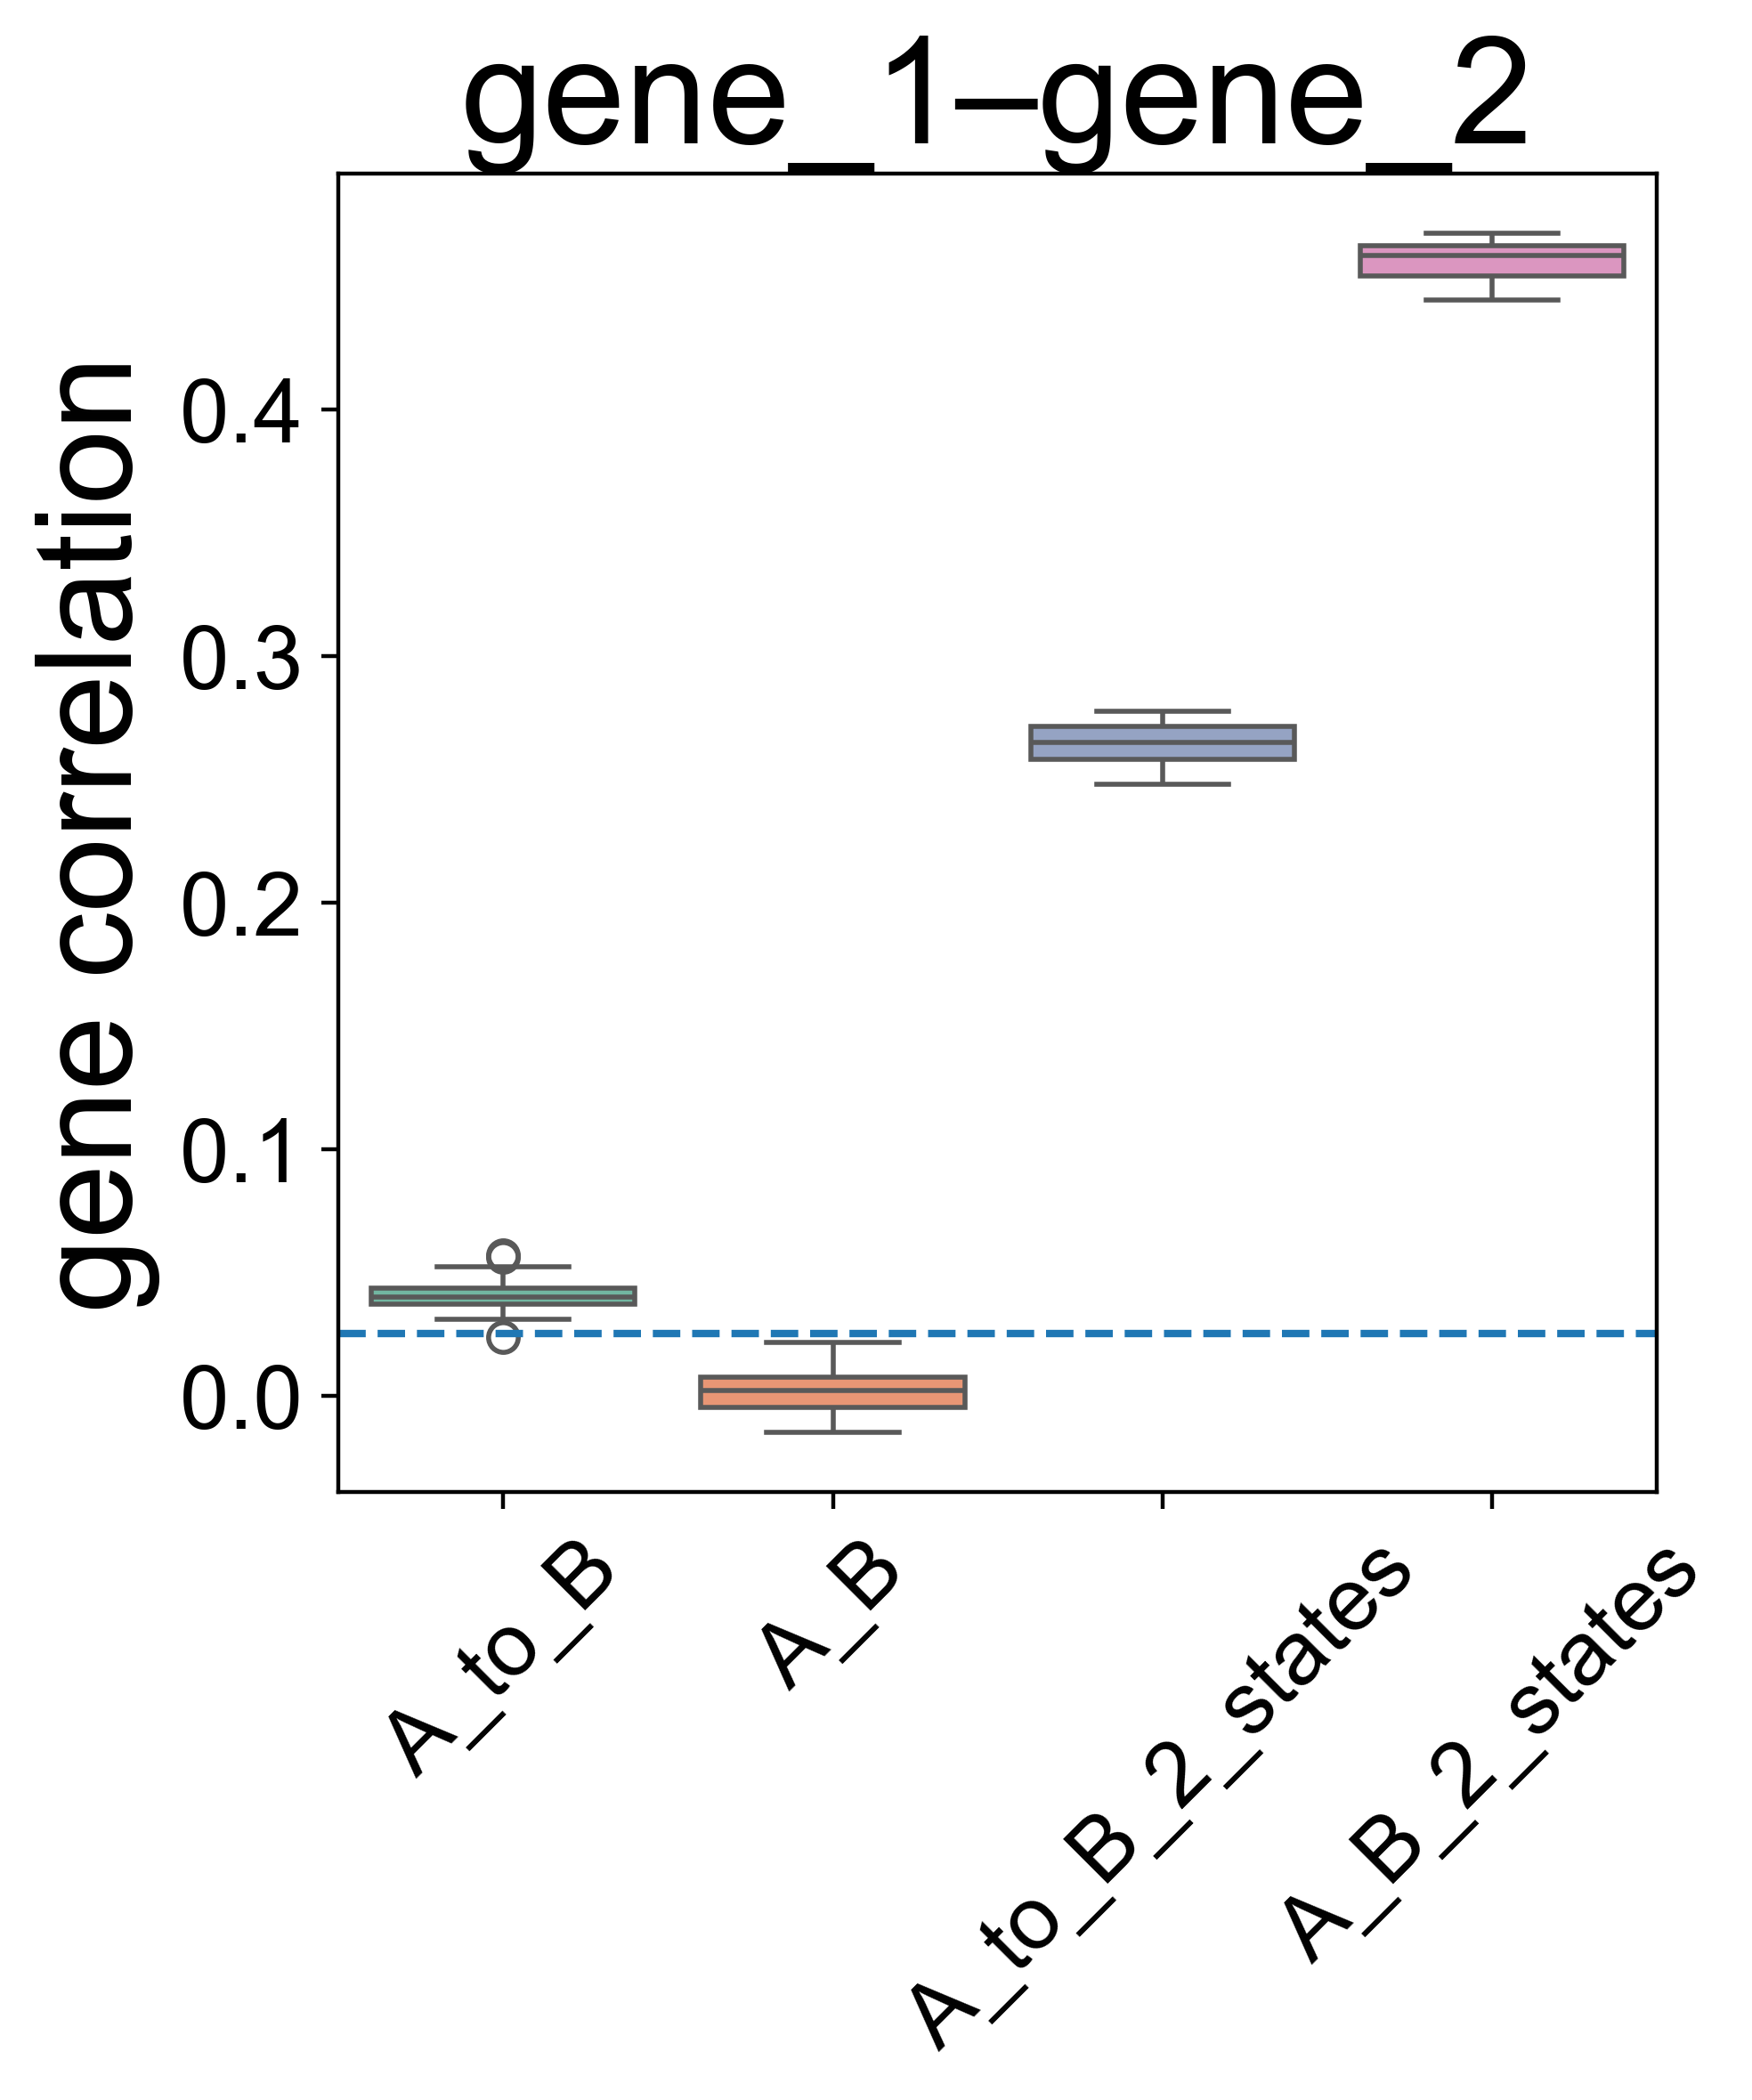

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(f"{path_to_plot_data}/gene_gene_matrix_results.csv")
df['sim_type'] = df['sim_type'].str.replace("_New_Median", "", regex=False)
# ---------------------------------------------
# Convert wide format → long format
# ---------------------------------------------
value_cols = [c for c in df.columns if c.startswith("g")]
keep_cols = ["g1_g2"]

df_selected = df[["sim_type"] + keep_cols].copy()

df_long = df_selected.melt(
    id_vars="sim_type",
    value_vars=keep_cols,
    var_name="pair",
    value_name="value"
)

# Make pretty labels
pair_map = {
    "g1_g2": "gene_1–gene_2",
}
df_long["pair_str"] = df_long["pair"].map(pair_map)

# Unique ordered gene pairs
gene_pairs = ["gene_1–gene_2"]


fig, axes = plt.subplots(1, len(gene_pairs), figsize=(5*len(gene_pairs), 6), sharey=True)

if len(gene_pairs) == 1:
    axes = [axes]

for ax, gp in zip(axes, gene_pairs):
    subset = df_long[df_long["pair_str"] == gp]

    sns.boxplot(
        data=subset,
        x="sim_type".replace("New_median", ""),
        y="value",
        ax=ax,
        palette="Set2"
    )
    ax.axhline(y= threshold, linestyle = "--")
    ax.set_title(gp)
    ax.set_xlabel("")
    ax.set_ylabel("gene correlation")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from scipy.stats import spearmanr

#Functions to calculate cross-correlations for multiple replicates. Same idea as step 3 of infer_with_twinfer pipeline - rewritten here for optimizing the input
# and output for this specific use-case

# ==========================================
# CORRELATION FUNCTIONS
# ==========================================
def compute_correlation_matrix_fast(gene_matrix_t1, gene_matrix_t2, gene_list, 
                                   gene_pairs=None, threshold=None):
    """Fast correlation computation using pure NumPy operations."""
    n_genes = len(gene_list)
    gene_to_idx = {gene: i for i, gene in enumerate(gene_list)}
    
    # Initialize matrices
    raw_matrix = np.zeros((n_genes, n_genes))
    
    # Determine which pairs to compute
    if gene_pairs is None:
        pairs_to_compute = [(i, j) for i in range(n_genes) for j in range(n_genes)]
    else:
        pairs_to_compute = []
        for gene_1, gene_2 in gene_pairs:
            if gene_1 in gene_to_idx and gene_2 in gene_to_idx:
                i, j = gene_to_idx[gene_1], gene_to_idx[gene_2]
                pairs_to_compute.append((i, j))
    
    # Compute correlations for specified pairs
    for i, j in pairs_to_compute:
        corr = spearmanr(gene_matrix_t1[i, :], gene_matrix_t2[j, :]).correlation
        if np.isnan(corr):
            corr = 0.0
        raw_matrix[i, j] = corr
    
    # Convert to DataFrames
    raw_df = pd.DataFrame(raw_matrix, index=gene_list, columns=gene_list)
    return {"raw_matrix": raw_df}

def single_cell_shuffle(gene_matrix_t1, gene_matrix_t2, gene_list, gene_pairs, threshold):
    """Perform a single cell shuffling iteration."""
    n_cells = gene_matrix_t1.shape[1]
    shuffled_indices = np.random.permutation(n_cells)
    shuffled_matrix_t2 = gene_matrix_t2[:, shuffled_indices]
    return compute_correlation_matrix_fast(gene_matrix_t1, shuffled_matrix_t2, gene_list, gene_pairs, threshold)

def prepare_twin_data(df, gene_list, t1=10, t2=20):
    """
    Prepare twin data from simulation CSV file.
    Based on your data loading process.
    """
    # Basic checks
    if 'clone_id' not in df.columns:
        raise ValueError("CSV must contain 'clone_id' column")
    if 'time_step' not in df.columns:
        raise ValueError("CSV must contain 'time_step' column")
    
    n_clones_simulation = df['clone_id'].nunique()
    
    # Shuffle all clone IDs (like in your code)
    np.random.seed(101010)
    clone_ids_shuffled = np.random.permutation(n_clones_simulation)
    
    # Split into ratios (like in your code)
    n1 = n2 = n_clones_simulation // 4
    across_t_clones = clone_ids_shuffled[n1 + n2:]
    
    # Get across-time twins (like in your code)
    across_t_twin1 = df[
        (df['clone_id'].isin(across_t_clones)) & 
        (df['time_step'] == t1) & 
        (df['replicate'] == 1)
    ].reset_index(drop=True)
    
    across_t_twin2 = df[
        (df['clone_id'].isin(across_t_clones)) & 
        (df['time_step'] == t2) & 
        (df['replicate'] == 2)
    ].reset_index(drop=True)
    
    return across_t_twin1, across_t_twin2

def analyze_single_file(file_path, gene_list, t1=1, t2=20, n_shuffles=10000, threshold=0.02):
    """
    Analyze a single CSV file to get correlations and thresholds.
    """
    
    print(f"  Analyzing {os.path.basename(file_path)}")
    
    # Load data
    df = pd.read_csv(file_path)
    
    # Prepare twin data
    rep_0_t1, rep_1_t2 = prepare_twin_data(df, gene_list, t1, t2)
    
    if len(rep_0_t1) == 0 or len(rep_1_t2) == 0:
        print(f"    Warning: No twin data found")
        return None
    
    # Extract gene matrices
    gene_matrix_t1 = []
    gene_matrix_t2 = []
    
    for gene in gene_list:
        # Look for gene columns
        gene_col_t1 = f"{gene}_mRNA" if f"{gene}_mRNA" in rep_0_t1.columns else None
        gene_col_t2 = f"{gene}_mRNA" if f"{gene}_mRNA" in rep_1_t2.columns else None
        
        if not gene_col_t1:
            matching_cols = [col for col in rep_0_t1.columns if gene in col and 'mRNA' in col]
            gene_col_t1 = matching_cols[0] if matching_cols else None
            
        if not gene_col_t2:
            matching_cols = [col for col in rep_1_t2.columns if gene in col and 'mRNA' in col]
            gene_col_t2 = matching_cols[0] if matching_cols else None
        
        if gene_col_t1 and gene_col_t2:
            gene_matrix_t1.append(rep_0_t1[gene_col_t1].values)
            gene_matrix_t2.append(rep_1_t2[gene_col_t2].values)
        else:
            print(f"    Warning: Could not find {gene} data")
            return None
    
    gene_matrix_t1 = np.array(gene_matrix_t1)
    gene_matrix_t2 = np.array(gene_matrix_t2)
    
    gene_pairs = [('gene_1', 'gene_2'), ('gene_2', 'gene_1'), ('gene_1', 'gene_1'), ('gene_2', 'gene_2')]
    
    # Get actual correlations
    actual_results = compute_correlation_matrix_fast(gene_matrix_t1, gene_matrix_t2, gene_list, gene_pairs, None)
    actual_matrix = actual_results['raw_matrix']
    
    gene_1_to_2 = actual_matrix.loc['gene_1', 'gene_2']
    gene_2_to_1 = actual_matrix.loc['gene_2', 'gene_1']
    
    # Get shuffled correlations for thresholds
    shuffled_results = Parallel(n_jobs=-1, verbose=0)(
        delayed(single_cell_shuffle)(gene_matrix_t1, gene_matrix_t2, gene_list, gene_pairs, None)
        for _ in range(n_shuffles)
    )
    
    # Calculate thresholds
    shuffled_12 = []
    shuffled_21 = []
    
    for result in shuffled_results:
        shuffled_matrix = result['raw_matrix']
        shuffled_12.append((shuffled_matrix.loc['gene_1', 'gene_2']))
        shuffled_21.append((shuffled_matrix.loc['gene_2', 'gene_1']))

    # Calculate threshold for this pair: gene 1 -> gene 2
    p_plus_12 = np.mean(shuffled_12 >= gene_1_to_2)
    p_minus_12 = np.mean(shuffled_12 <= gene_1_to_2)
    p_value_12 = min(2 * p_plus_12, 2 * p_minus_12, 1.0)
    is_significant_12 = p_value_12 < threshold
    print(f"Observed correlation: {gene_1_to_2:.4f}")
    print(f"p-value: {p_value_12:.4f}")
    print(f"Significant at α={threshold}: {is_significant_12}")

    # Calculate threshold for this pair: gene 1 -> gene 2
    p_plus_21 = np.mean(shuffled_21 >= gene_2_to_1)
    p_minus_21 = np.mean(shuffled_21 <= gene_2_to_1)
    p_value_21 = min(2 * p_plus_21, 2 * p_minus_21, 1.0)
    is_significant_21 = p_value_21 < threshold
    print(f"Observed correlation: {gene_2_to_1:.4f}")
    print(f"p-value: {p_value_21:.4f}")
    print(f"Significant at α={threshold}: {is_significant_21}")
    
    threshold_12 = max(
        abs(np.percentile(shuffled_12, 1)),
        abs(np.percentile(shuffled_12, 99))
    )
    threshold_21 = max(
        abs(np.percentile(shuffled_21, 1)),
        abs(np.percentile(shuffled_21, 99))
    )

    combined_null = np.concatenate([shuffled_12, shuffled_21])
    threshold_combined = max(
        abs(np.percentile(combined_null, 1)),
        abs(np.percentile(combined_null, 99))
    )

    
    print(f"    Correlations: gene_1→gene_2={gene_1_to_2:.3f}, gene_2→gene_1={gene_2_to_1:.3f}")
    print(f"    Thresholds: gene_1→gene_2={threshold_12:.3f}, gene_2→gene_1={threshold_21:.3f}")
    
    return {
        'gene_1_to_gene_2': gene_1_to_2,
        'gene_2_to_gene_1': gene_2_to_1,
        'pvalue_12': p_value_12,
        'pvalue_21': p_value_21,
        'threshold_12': threshold_12,
        'threshold_21': threshold_21,
        'threshold_combined': threshold_combined
    }
# =========================================================================================================

def cross_correlation_data_across_replicates(base_path, folder_names, gene_list, t1=1, t2=20, n_shuffles=10000):
    """
    Collect correlations and thresholds from all files specified as this specific network type.
    """
    
    all_results = []
    
    for folder in folder_names:
        folder_path = os.path.join(base_path, folder)
        print(f"Processing {folder}...")
        
        if not os.path.exists(folder_path):
            print(f"  Folder not found: {folder_path}")
            continue
            
        # Find CSV files
        csv_files = [f for f in os.listdir(folder_path) if f.startswith('df_') and f.endswith('.csv') and ("0801" in f or "0901" in f)][:20]
        print(f"  Found {len(csv_files)} files")
        for csv_file in csv_files:
            file_path = os.path.join(folder_path, csv_file)
            print(csv_file)
            try:
                result = analyze_single_file(file_path, gene_list, t1, t2, n_shuffles)
                
                if result:
                    result['Condition'] = folder
                    result['File'] = csv_file
                    all_results.append(result)
                    
            except Exception as e:
                print(f"    Error with {csv_file}: {e}")
                continue
    
    return pd.DataFrame(all_results)

/tmp/ipykernel_872731/2456893191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_872731/2456893191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_872731/2456893191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


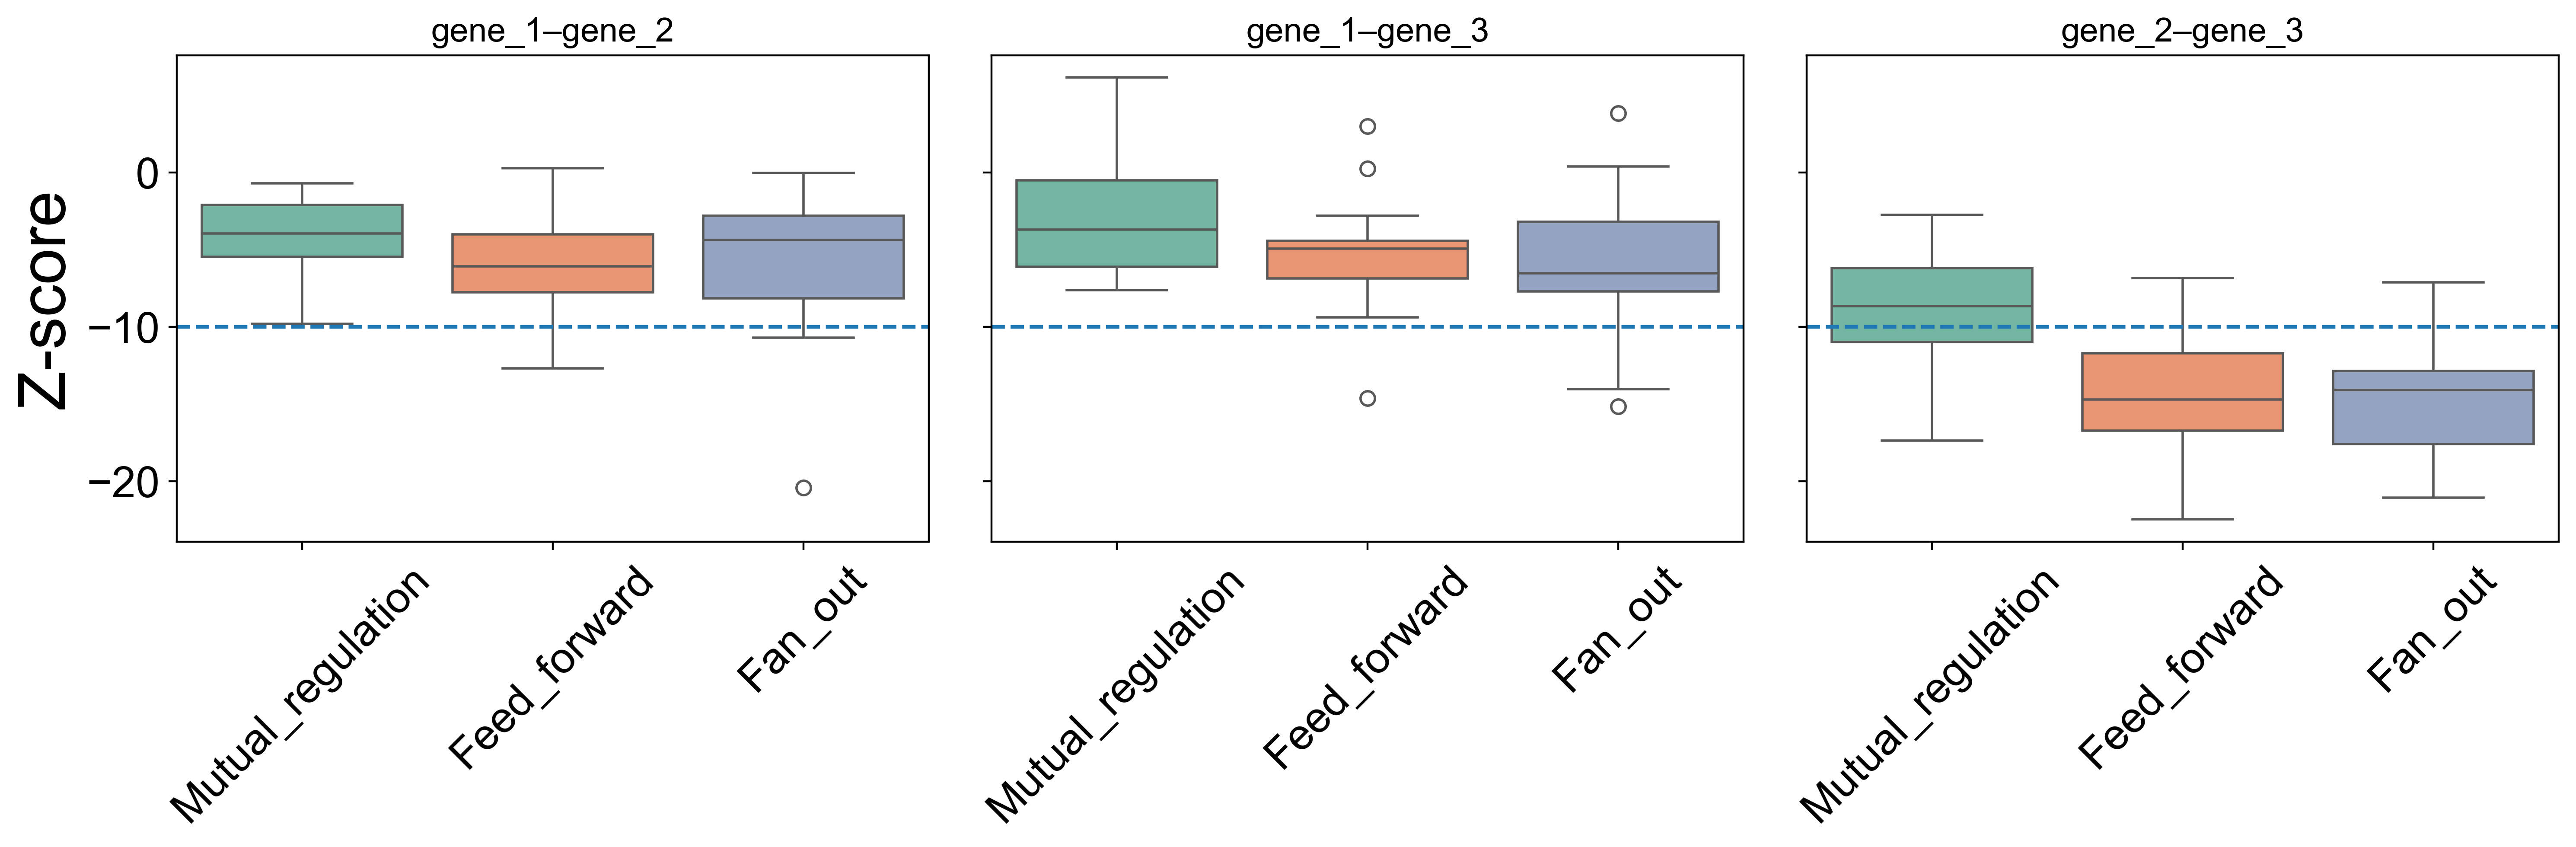

In [102]:
# Parameters
sub_folder_names = ["A_B", "A_to_B"]
gene_list = ['gene_1', 'gene_2']
t1, t2 = 1, 20  # Adjust these to your time points
n_shuffles = 10000  # Number of shuffles for threshold calculation

# Collect all data
print("\n1. Collecting data from all files...")
df_results = cross_correlation_data_across_replicates(path_to_simulation_data, sub_folder_names, gene_list, t1, t2, n_shuffles)

if df_results.empty:
    print("No data collected!")
else:
    df_results.to_csv(f"{path_to_plot_data}/box_plot_data.csv")
print(f"Collected {len(df_results)} files from {df_results['Condition'].nunique()} conditions")

# Summary stats
print("\n4. Summary statistics:")
summary = df_results.groupby('Condition')[['gene_1_to_gene_2', 'gene_2_to_gene_1']].describe()
print(summary)



In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from scipy.stats import spearmanr

#Functions to calculate cross-correlations for multiple replicates. Same idea as step 3 of infer_with_twinfer pipeline - rewritten here for optimizing the input
# and output for this specific use-case

# ==========================================
# CORRELATION FUNCTIONS
# ==========================================
def compute_correlation_matrix_fast(gene_matrix_t1, gene_matrix_t2, gene_list, 
                                   gene_pairs=None, threshold=None):
    """Fast correlation computation using pure NumPy operations."""
    n_genes = len(gene_list)
    gene_to_idx = {gene: i for i, gene in enumerate(gene_list)}
    
    # Initialize matrices
    raw_matrix = np.zeros((n_genes, n_genes))
    
    # Determine which pairs to compute
    if gene_pairs is None:
        pairs_to_compute = [(i, j) for i in range(n_genes) for j in range(n_genes)]
    else:
        pairs_to_compute = []
        for gene_1, gene_2 in gene_pairs:
            if gene_1 in gene_to_idx and gene_2 in gene_to_idx:
                i, j = gene_to_idx[gene_1], gene_to_idx[gene_2]
                pairs_to_compute.append((i, j))
    
    # Compute correlations for specified pairs
    for i, j in pairs_to_compute:
        corr = spearmanr(gene_matrix_t1[i, :], gene_matrix_t2[j, :]).correlation
        if np.isnan(corr):
            corr = 0.0
        raw_matrix[i, j] = corr
    
    # Convert to DataFrames
    raw_df = pd.DataFrame(raw_matrix, index=gene_list, columns=gene_list)
    return {"raw_matrix": raw_df}

def single_cell_shuffle(gene_matrix_t1, gene_matrix_t2, gene_list, gene_pairs, threshold):
    """Perform a single cell shuffling iteration."""
    n_cells = gene_matrix_t1.shape[1]
    shuffled_indices = np.random.permutation(n_cells)
    shuffled_matrix_t2 = gene_matrix_t2[:, shuffled_indices]
    return compute_correlation_matrix_fast(gene_matrix_t1, shuffled_matrix_t2, gene_list, gene_pairs, threshold)

def prepare_twin_data(df, gene_list, t1=10, t2=20):
    """
    Prepare twin data from simulation CSV file.
    Based on your data loading process.
    """
    # Basic checks
    if 'clone_id' not in df.columns:
        raise ValueError("CSV must contain 'clone_id' column")
    if 'time_step' not in df.columns:
        raise ValueError("CSV must contain 'time_step' column")
    
    n_clones_simulation = df['clone_id'].nunique()
    
    # Shuffle all clone IDs (like in your code)
    np.random.seed(101010)
    clone_ids_shuffled = np.random.permutation(n_clones_simulation)
    
    # Split into ratios (like in your code)
    n1 = n2 = n_clones_simulation // 4
    across_t_clones = clone_ids_shuffled[n1 + n2:]
    
    # Get across-time twins (like in your code)
    across_t_twin1 = df[
        (df['clone_id'].isin(across_t_clones)) & 
        (df['time_step'] == t1) & 
        (df['replicate'] == 1)
    ].reset_index(drop=True)
    
    across_t_twin2 = df[
        (df['clone_id'].isin(across_t_clones)) & 
        (df['time_step'] == t2) & 
        (df['replicate'] == 2)
    ].reset_index(drop=True)
    
    return across_t_twin1, across_t_twin2

def analyze_single_file(file_path, gene_list, t1=1, t2=20, n_shuffles=10000, threshold=0.02):
    """
    Analyze a single CSV file to get correlations and thresholds.
    """
    
    print(f"  Analyzing {os.path.basename(file_path)}")
    
    # Load data
    df = pd.read_csv(file_path)
    
    # Prepare twin data
    rep_0_t1, rep_1_t2 = prepare_twin_data(df, gene_list, t1, t2)
    
    if len(rep_0_t1) == 0 or len(rep_1_t2) == 0:
        print(f"    Warning: No twin data found")
        return None
    
    # Extract gene matrices
    gene_matrix_t1 = []
    gene_matrix_t2 = []
    
    for gene in gene_list:
        # Look for gene columns
        gene_col_t1 = f"{gene}_mRNA" if f"{gene}_mRNA" in rep_0_t1.columns else None
        gene_col_t2 = f"{gene}_mRNA" if f"{gene}_mRNA" in rep_1_t2.columns else None
        
        if not gene_col_t1:
            matching_cols = [col for col in rep_0_t1.columns if gene in col and 'mRNA' in col]
            gene_col_t1 = matching_cols[0] if matching_cols else None
            
        if not gene_col_t2:
            matching_cols = [col for col in rep_1_t2.columns if gene in col and 'mRNA' in col]
            gene_col_t2 = matching_cols[0] if matching_cols else None
        
        if gene_col_t1 and gene_col_t2:
            gene_matrix_t1.append(rep_0_t1[gene_col_t1].values)
            gene_matrix_t2.append(rep_1_t2[gene_col_t2].values)
        else:
            print(f"    Warning: Could not find {gene} data")
            return None
    
    gene_matrix_t1 = np.array(gene_matrix_t1)
    gene_matrix_t2 = np.array(gene_matrix_t2)
    
    gene_pairs = [('gene_1', 'gene_2'), ('gene_2', 'gene_1'), ('gene_1', 'gene_1'), ('gene_2', 'gene_2')]
    
    # Get actual correlations
    actual_results = compute_correlation_matrix_fast(gene_matrix_t1, gene_matrix_t2, gene_list, gene_pairs, None)
    actual_matrix = actual_results['raw_matrix']
    
    gene_1_to_2 = actual_matrix.loc['gene_1', 'gene_2']
    gene_2_to_1 = actual_matrix.loc['gene_2', 'gene_1']
    
    # Get shuffled correlations for thresholds
    shuffled_results = Parallel(n_jobs=-1, verbose=0)(
        delayed(single_cell_shuffle)(gene_matrix_t1, gene_matrix_t2, gene_list, gene_pairs, None)
        for _ in range(n_shuffles)
    )
    
    # Calculate thresholds
    shuffled_12 = []
    shuffled_21 = []
    
    for result in shuffled_results:
        shuffled_matrix = result['raw_matrix']
        shuffled_12.append((shuffled_matrix.loc['gene_1', 'gene_2']))
        shuffled_21.append((shuffled_matrix.loc['gene_2', 'gene_1']))

    # Calculate threshold for this pair: gene 1 -> gene 2
    p_plus_12 = np.mean(shuffled_12 >= gene_1_to_2)
    p_minus_12 = np.mean(shuffled_12 <= gene_1_to_2)
    p_value_12 = min(2 * p_plus_12, 2 * p_minus_12, 1.0)
    is_significant_12 = p_value_12 < threshold
    print(f"Observed correlation: {gene_1_to_2:.4f}")
    print(f"p-value: {p_value_12:.4f}")
    print(f"Significant at α={threshold}: {is_significant_12}")

    # Calculate threshold for this pair: gene 1 -> gene 2
    p_plus_21 = np.mean(shuffled_21 >= gene_2_to_1)
    p_minus_21 = np.mean(shuffled_21 <= gene_2_to_1)
    p_value_21 = min(2 * p_plus_21, 2 * p_minus_21, 1.0)
    is_significant_21 = p_value_21 < threshold
    print(f"Observed correlation: {gene_2_to_1:.4f}")
    print(f"p-value: {p_value_21:.4f}")
    print(f"Significant at α={threshold}: {is_significant_21}")
    
    threshold_12 = max(
        abs(np.percentile(shuffled_12, 1)),
        abs(np.percentile(shuffled_12, 99))
    )
    threshold_21 = max(
        abs(np.percentile(shuffled_21, 1)),
        abs(np.percentile(shuffled_21, 99))
    )

    combined_null = np.concatenate([shuffled_12, shuffled_21])
    threshold_combined = max(
        abs(np.percentile(combined_null, 1)),
        abs(np.percentile(combined_null, 99))
    )

    
    print(f"    Correlations: gene_1→gene_2={gene_1_to_2:.3f}, gene_2→gene_1={gene_2_to_1:.3f}")
    print(f"    Thresholds: gene_1→gene_2={threshold_12:.3f}, gene_2→gene_1={threshold_21:.3f}")
    
    return {
        'gene_1_to_gene_2': gene_1_to_2,
        'gene_2_to_gene_1': gene_2_to_1,
        'pvalue_12': p_value_12,
        'pvalue_21': p_value_21,
        'threshold_12': threshold_12,
        'threshold_21': threshold_21,
        'threshold_combined': threshold_combined
    }
# =========================================================================================================

def cross_correlation_data_across_replicates(base_path, folder_names, gene_list, t1=1, t2=20, n_shuffles=10000):
    """
    Collect correlations and thresholds from all files specified as this specific network type.
    """
    
    all_results = []
    
    for folder in folder_names:
        folder_path = os.path.join(base_path, folder)
        print(f"Processing {folder}...")
        
        if not os.path.exists(folder_path):
            print(f"  Folder not found: {folder_path}")
            continue
            
        # Find CSV files
        csv_files = [f for f in os.listdir(folder_path) if f.startswith('df_') and f.endswith('.csv') and "bias_0.5_" in f][:20]
        print(f"  Found {len(csv_files)} files")
        for csv_file in csv_files:
            file_path = os.path.join(folder_path, csv_file)
            print(csv_file)
            try:
                result = analyze_single_file(file_path, gene_list, t1, t2, n_shuffles)
                
                if result:
                    result['Condition'] = folder
                    result['File'] = csv_file
                    all_results.append(result)
                    
            except Exception as e:
                print(f"    Error with {csv_file}: {e}")
                continue
    
    return pd.DataFrame(all_results)

# Parameters
sub_folder_names = ["A_B", "A_to_B"]
gene_list = ['gene_1', 'gene_2']
t1, t2 = 1, 20  # Adjust these to your time points
n_shuffles = 10000  # Number of shuffles for threshold calculation

# Collect all data
print("\n1. Collecting data from all files...")
df_results = cross_correlation_data_across_replicates(path_to_simulation_data, sub_folder_names, gene_list, t1, t2, n_shuffles)

if df_results.empty:
    print("No data collected!")
else:
    df_results.to_csv(f"{path_to_plot_data}/box_plot_data.csv")
print(f"Collected {len(df_results)} files from {df_results['Condition'].nunique()} conditions")

# Summary stats
print("\n4. Summary statistics:")
summary = df_results.groupby('Condition')[['gene_1_to_gene_2', 'gene_2_to_gene_1']].describe()
print(summary)



1. Collecting data from all files...
Processing A_B...
  Found 20 files
df_rows_0_0_06022026_160944_ncells_6000_A_B_bias_0.5_6_b7045d6e.csv
  Analyzing df_rows_0_0_06022026_160944_ncells_6000_A_B_bias_0.5_6_b7045d6e.csv
Observed correlation: -0.0015
p-value: 0.9302
Significant at α=0.02: False
Observed correlation: 0.0073
p-value: 0.6908
Significant at α=0.02: False
    Correlations: gene_1→gene_2=-0.001, gene_2→gene_1=0.007
    Thresholds: gene_1→gene_2=0.043, gene_2→gene_1=0.043
df_rows_0_0_06022026_163206_ncells_6000_A_B_bias_0.5_16_a8ea3d86.csv
  Analyzing df_rows_0_0_06022026_163206_ncells_6000_A_B_bias_0.5_16_a8ea3d86.csv
Observed correlation: 0.0245
p-value: 0.1732
Significant at α=0.02: False
Observed correlation: 0.0268
p-value: 0.1430
Significant at α=0.02: False
    Correlations: gene_1→gene_2=0.025, gene_2→gene_1=0.027
    Thresholds: gene_1→gene_2=0.044, gene_2→gene_1=0.044
df_rows_0_0_06022026_162525_ncells_6000_A_B_bias_0.5_13_1a8b22ce.csv
  Analyzing df_rows_0_0_060220